In [1]:
print("test")

test


In [20]:
"""
Configuration des variables d'environnement pour l'API OpenAI
Ce module charge la clé API nécessaire pour authentifier les requêtes auprès d'OpenAI.
"""
# Import des bibliothèques nécessaires
from dotenv import load_dotenv # Pour charger les variables depuis .env
import os # Pour accéder aux variables d'environnement système

# Charge automatiquement les variables définies dans le fichier .env
# Le fichier .env doit être placé à la racine du projet
load_dotenv()

# Récupération sécurisée de la clé API OpenAI
# La clé doit être définie dans le fichier .env comme : OPENAI_API_KEY=votre_clé_ici
api_key = os.getenv("OPENAI_API_KEY")

In [21]:
"""
Configuration de l'encodage et des variables d'environnement pour OpenAI
"""
# Import de tiktoken pour la gestion du tokenizer OpenAI (comptage des tokens)
import tiktoken

# Import spécifique pour charger les variables d'environnement dans Jupyter/IPython
# load_dotenv() recherchera le fichier .env dans le répertoire courant
from dotenv.ipython import load_dotenv

# Module standard pour interagir avec le système d'exploitation
import os

In [22]:
"""
Chargement du fichier .env avec priorité absolue
Paramètre override=True : force l'utilisation des valeurs du .env
même si des variables du même nom existent déjà dans l'environnement système.
"""

# override=True permet de remplacer les variables système existantes par celles définies dans le fichier .env
load_dotenv(override=True)

True

In [23]:
# Initialisation du tokenizer spécifique au modèle GPT-4o
# Cette fonction charge automatiquement l'encodeur optimal pour le modèle spécifié
tokennizer = tiktoken.encoding_for_model("gpt-4o")

# Affiche le nom de l'encodeur utilisé (ex: "o200k_base" pour GPT-4o)
# Permet de vérifier visuellement quel tokenizer est actif
print(tokennizer.name)

o200k_base


In [24]:
# Définition du prompt système qui établit le rôle et l'expertise de l'assistant
# Ce prompt sert à contextualiser le comportement de l'IA
prompt = "Vous êtes un assistant expert dans le domaine de l'analyse"

In [25]:
# Conversion du prompt en tokens (représentation numérique)
# tokennizer.encode() transforme le texte en une liste d'entiers
tokens=tokennizer.encode(prompt)

In [26]:
# Visualisation de la longueur du prompt en termes de tokens
print(len(tokens))

11


In [27]:
"""
Visualisation de la segmentation du texte en tokens
Cette boucle permet de comprendre comment le tokenizer découpe notre texte
"""
# Parcours de chaque identifiant de token dans la liste
for token in tokens:
    # Étape 1: decode_single_token_bytes() convertit l'ID du token en bytes
    # Étape 2: .decode('utf-8') transforme ces bytes en texte lisible
    t=tokennizer.decode_single_token_bytes(token).decode('utf-8')
    # Affiche le token suivi d'un séparateur |
    print(t, end="|")

Vous| êtes| un| assistant| expert| dans| le| domaine| de| l|'analyse|

In [29]:
def tokens_count(prompt:str, model:str="o200k_base"):
    """
    Compte le nombre de tokens dans un prompt donné
    """
    tokennizer = tiktoken.get_encoding(model)
    return len(tokennizer.encode(prompt))

In [30]:
# Test de la fonction de comptage de tokens sur un prompt simple
# Affiche le nombre de tokens pour "Vous êtes un assistant"
print(tokens_count(prompt="Vous êtes un assistant"))

4


In [31]:
# Import de la classe ChatOpenAI depuis LangChain
# LangChain fournit une interface unifiée pour interagir avec les modèles OpenAI
from langchain_openai import ChatOpenAI

# Initialisation du modèle de chat GPT-4o avec une température de 0
# Temperature=0 rend les réponses déterministes (toujours la même réponse pour le même prompt)
llm = ChatOpenAI(model="gpt-4o", temperature=0)

In [32]:
# === INTERACTION AVEC LE MODÈLE VIA LANGCHAIN ===  
# Appel au modèle avec une conversation structurée
# La liste de messages définit le contexte (system) et la question (user)
resp=llm.invoke(input=[
    {"role":"system","content":"you are a helpful assistant"},
    {"role":"user","content":"c'est quoi un agent ai"}
])

In [ ]:
# === AFFICHAGE FORMATÉ DANS JUPYTER NOTEBOOK ===
# Import du module d'affichage de IPython spécifique aux notebooks
from IPython.display import Markdown

In [ ]:
# Affiche la réponse du modèle en format Markdown dans le notebook
# display() rend le contenu formaté, print() ajoute un 'None' supplémentaire
print(display(Markdown(resp.content)))

Un agent AI (ou agent intelligent) est un programme informatique conçu pour percevoir son environnement, prendre des décisions et agir de manière autonome pour atteindre des objectifs spécifiques. Les agents AI peuvent être simples ou complexes, et ils sont utilisés dans une variété de domaines, tels que :

1. **Assistants virtuels** : Comme Siri, Alexa ou Google Assistant, qui aident les utilisateurs à accomplir des tâches en répondant à des questions, en envoyant des messages, en réglant des alarmes, etc.

2. **Agents conversationnels** : Comme les chatbots, qui interagissent avec les utilisateurs via des interfaces de chat pour fournir des informations ou des services.

3. **Systèmes de recommandation** : Qui suggèrent des produits, des films, de la musique, etc., en fonction des préférences de l'utilisateur.

4. **Agents autonomes** : Comme les voitures autonomes, qui perçoivent leur environnement et prennent des décisions de conduite sans intervention humaine.

5. **Jeux vidéo** : Où les agents AI contrôlent les personnages non-joueurs (PNJ) pour offrir des défis aux joueurs.

Les agents AI utilisent souvent des techniques d'apprentissage automatique, de traitement du langage naturel, de vision par ordinateur, et d'autres domaines de l'intelligence artificielle pour accomplir leurs tâches.

None


In [ ]:
# Import de ChatOllama depuis LangChain pour utiliser des modèles locaux via Ollama
from langchain_ollama import ChatOllama

In [ ]:
# Initialisation d'un second modèle LLM avec Llama 3.2 via Ollama
# Ollama permet d'exécuter des modèles en local sans passer par OpenAI
llm2 = ChatOllama(model="llama3.2")

In [ ]:
# Appel au modèle local avec la même conversation que précédemment
# Permet de comparer les réponses entre GPT-4o (cloud) et Llama 3.2 (local)
resp=llm2.invoke(input=[
    {"role":"system","content":"you are a helpful assistant"},
    {"role":"user","content":"c'est quoi un agent ai"}
])

In [33]:
# Affichage de la réponse du modèle local en Markdown
print(display(Markdown(resp.content)))

Un agent AI (ou agent d'intelligence artificielle) est un programme informatique conçu pour effectuer des tâches spécifiques ou résoudre des problèmes en utilisant des techniques d'intelligence artificielle. Ces agents peuvent percevoir leur environnement, prendre des décisions basées sur ces perceptions et agir en conséquence pour atteindre des objectifs définis.

Les agents AI peuvent être classés en plusieurs catégories selon leur complexité et leurs capacités :

1. **Agents réactifs simples** : Ces agents prennent des décisions basées uniquement sur l'information actuelle de l'environnement, sans utiliser d'historique. Ils suivent des règles prédéfinies pour réagir à des situations spécifiques.

2. **Agents basés sur un modèle** : Ces agents maintiennent un modèle interne de l'état du monde, ce qui leur permet de prendre en compte l'historique des événements pour prendre des décisions plus éclairées.

3. **Agents orientés objectifs** : En plus de maintenir un modèle du monde, ces agents ont des objectifs spécifiques qu'ils essaient d'atteindre. Ils planifient leurs actions en fonction de ces objectifs.

4. **Agents apprenants** : Ces agents peuvent améliorer leurs performances au fil du temps en apprenant de leurs expériences passées. Ils utilisent des techniques d'apprentissage automatique pour adapter leur comportement.

5. **Agents autonomes** : Ils sont capables de fonctionner de manière indépendante dans des environnements complexes et dynamiques, en prenant des décisions sans intervention humaine.

Les agents AI sont utilisés dans de nombreux domaines, tels que les assistants virtuels (comme Siri ou Alexa), les systèmes de recommandation, les jeux vidéo, la robotique, et bien d'autres applications.

None


In [34]:
# Import du module ChatGroq depuis LangChain pour utiliser l'API Groq
from langchain_groq import ChatGroq

In [35]:
# Initialisation d'un troisième modèle via Groq avec GPT-OSS-120B
# openai/gpt-oss-120b est un modèle open source compatible avec l'API OpenAI
llm3=ChatGroq(model="openai/gpt-oss-120b")

In [36]:
# Appel au modèle Groq avec la même conversation
# Permet de comparer les réponses entre OpenAI (cloud), Ollama (local) et Groq (ultra-rapide)
resp=llm3.invoke(input=[
    {"role":"system","content":"you are a helpful assistant"},
    {"role":"user","content":"c'est quoi un agent ai"}
])

In [37]:
# Affichage de la réponse du modèle Groq en Markdown
print(display(Markdown(resp.content)))

**Un agent IA (ou « agent d’intelligence artificielle »)** est un système logiciel capable d’observer son environnement, de prendre des décisions et d’agir en fonction de ces observations, le tout en s’appuyant sur des techniques d’intelligence artificielle (apprentissage automatique, logique, planification, etc.).  

En d’autres termes, c’est un « programme autonome » qui perçoit, raisonne et agit pour atteindre un ou plusieurs objectifs.

---

## 1. Les composantes d’un agent IA

| Composante | Rôle |
|------------|------|
| **Capteur(s)** (ou entrée) | Capture les données de l’environnement (texte, images, sons, mesures de capteurs, état du jeu, etc.). |
| **Modèle/Algorithme d’IA** | Analyse les données, prédit des résultats, planifie ou décide de la meilleure action (réseaux de neurones, arbres de décision, logique floue, RL, etc.). |
| **Moteur de décision** | Sélectionne l’action à exécuter parmi les possibilités (politique, fonction de valeur, règle de décision). |
| **Effecteur(s)** (ou sortie) | Met en œuvre l’action choisie (affichage d’un texte, mouvement d’un robot, envoi d’une requête, modification d’un fichier, etc.). |
| **Boucle de rétroaction** | L’agent observe les conséquences de son action, ajuste son comportement et répète le cycle. |

---

## 2. Types d’agents IA

| Type d’agent | Description | Exemples concrets |
|--------------|-------------|-------------------|
| **Agent réactif simple** | Réagit directement aux stimuli sans mémoire ni planification. | Chatbot à réponses pré‑définies, thermostat qui ajuste la température. |
| **Agent réactif avec mémoire** | Garde un historique court pour améliorer les réponses. | Systèmes de recommandation qui tiennent compte des dernières interactions. |
| **Agent basé sur la planification** | Construit un plan à l’avance en anticipant les conséquences. | Robot de livraison qui calcule un itinéraire optimal. |
| **Agent d’apprentissage (RL)** | Apprend par essais‑erreurs en maximisant une récompense cumulée. | Agents de jeu (AlphaGo, OpenAI Five), agents de trading automatisé. |
| **Agent multi‑modal** | Combine plusieurs types de capteurs (vision, audio, texte) et peut interagir dans différents médias. | Assistants vocaux (Siri, Alexa) qui comprennent la parole, affichent du texte et contrôlent des appareils. |
| **Agent social / collaboratif** | Interagit avec d’autres agents ou humains en coopération ou compétition. | Agents de simulation de foule, bots de négociation, assistants de travail collaboratif. |

---

## 3. Où retrouve‑t‑on des agents IA ?

| Domaine | Applications d’agents IA |
|---------|---------------------------|
| **Domotique** | Thermostats intelligents, éclairage adaptatif, assistants vocaux. |
| **Transport** | Voitures autonomes, systèmes d’aide à la conduite, gestion de flotte. |
| **Jeux vidéo** | PNJ (personnages non‑joueurs) qui s’adaptent au style du joueur, IA de stratégie. |
| **Finance** | Algorithmes de trading, détection de fraude, conseillers financiers virtuels. |
| **Santé** | Robots d’assistance, systèmes de diagnostic assisté, suivi de patients à distance. |
| **Service client** | Chatbots, agents de support qui résolvent des tickets ou orientent les utilisateurs. |
| **Industrie** | Robots de montage, maintenance prédictive, optimisation de la chaîne logistique. |
| **Recherche** | Agents qui parcourent le web, extraient des données, résument des articles. |

---

## 4. Différence entre *modèle d’IA* et *agent IA*

| Modèle d’IA | Agent IA |
|-------------|----------|
| **Ce que c’est** :** Un algorithme ou un réseau de neurones qui transforme des entrées en sorties (ex. : GPT‑4, ResNet).** | **Ce que c’est** :** Un système complet qui intègre un ou plusieurs modèles, des capteurs, un moteur de décision et des effecteurs.** |
| **Fonction principale** : prédire, classer, générer du texte, reconnaître des images, etc. | **Fonction principale** : percevoir, raisonner, agir dans un environnement réel ou simulé. |
| **Exemple** : un modèle de traduction qui prend du texte en entrée et renvoie la traduction. | **Exemple** : un robot de cuisine qui lit une recette (texte), identifie les ingrédients (vision), ajuste la température du four (action) et informe l’utilisateur du temps restant. |

---

## 5. Principaux défis liés aux agents IA

1. **Sécurité et fiabilité** – Un agent qui agit dans le monde réel doit être robuste aux erreurs et aux situations imprévues.  
2. **Éthique & biais** – Les décisions prises peuvent refléter les biais des données d’entraînement (ex. discrimination).  
3. **Explicabilité** – Comprendre pourquoi un agent a choisi une action est crucial, surtout dans les domaines critiques (santé, finance).  
4. **Interaction homme‑machine** – L’agent doit communiquer de façon claire et naturelle, gérer les ambiguïtés et les interruptions.  
5. **Gestion des ressources** – Temps de calcul, consommation d’énergie (ex. robots mobiles) et bande passante.

---

## 6. Exemple concret : un agent IA de recommandation de films

1. **Capteurs** : collecte du profil utilisateur (historique de visionnage, notes, genre préféré).  
2. **Modèle** : réseau de neurones collaborative filtering + embeddings de films.  
3. **Moteur de décision** : classe les films selon la probabilité d’appréciation et applique des règles (ex. éviter les contenus déjà vus).  
4. **Effecteur** : affiche une liste de 5 suggestions sur l’interface.  
5. **Boucle de rétroaction** : l’utilisateur note les suggestions, ce feedback est réinjecté pour affiner le modèle.

---

## 7. Ressources pour aller plus loin

| Type de ressource | Titre / lien | Pourquoi |
|-------------------|--------------|----------|
| **Cours en ligne** | *“Artificial Intelligence: Reinforcement Learning”* (Coursera) | Comprendre les agents qui apprennent par récompense. |
| **Livre** | *“Artificial Intelligence: A Modern Approach”* – Russell & Norvig | Fondamentaux théoriques des agents IA. |
| **Tutoriel** | *OpenAI Gym* (site) | Plateforme pour créer et tester des agents d’apprentissage par renforcement. |
| **Blog** | *DeepMind Blog* – articles sur AlphaGo, AlphaFold, etc. | Études de cas d’agents IA de pointe. |
| **Communauté** | *r/MachineLearning* sur Reddit | Discussions, questions, projets d’agents IA. |

---

### En résumé

Un **agent IA** est un système autonome qui perçoit son environnement, utilise des algorithmes d’intelligence artificielle pour raisonner, puis agit pour atteindre des objectifs. Il combine capteurs, modèles d’IA, logique de décision et effecteurs, et on le retrouve dans de nombreux domaines, du robot domestique aux assistants virtuels en passant par les voitures autonomes. La conception d’un tel agent implique non seulement des compétences techniques (machine learning, programmation, robotique) mais aussi une réflexion sur la sécurité, l’éthique et l’interaction avec les humains.

None


In [38]:
# === CONFIGURATION D'UN MODÈLE AVEC CAPACITÉS DE GÉNÉRATION D'IMAGE ===

# Initialisation d'un modèle GPT-5.2 (hypothétique) avec OpenAI
llm4= ChatOpenAI(model="gpt-5.2")

# Binding d'outils au modèle pour lui donner des capacités supplémentaires
# Ici on ajoute un outil de génération d'image avec paramètre de qualité
llm_with_tools = llm4.bind_tools([
    {"type":"image_generation", "quality":"high"}
])

In [39]:
# Import des types de messages standard de LangChain
from langchain.messages import SystemMessage, HumanMessage, AIMessage

In [40]:
# Appel au modèle avec outil pour générer une image
# Le modèle peut maintenant répondre avec des blocs de contenu variés (texte, image, etc.)
resp = llm_with_tools.invoke(input=[
    SystemMessage(""),
    HumanMessage("Je veux une image d'une femme noir ingénieur en informatique asise dans son bureau entrain de codé")

])

In [41]:
# Import pour l'affichage d'images dans le notebook
from IPython.display import Image
import base64

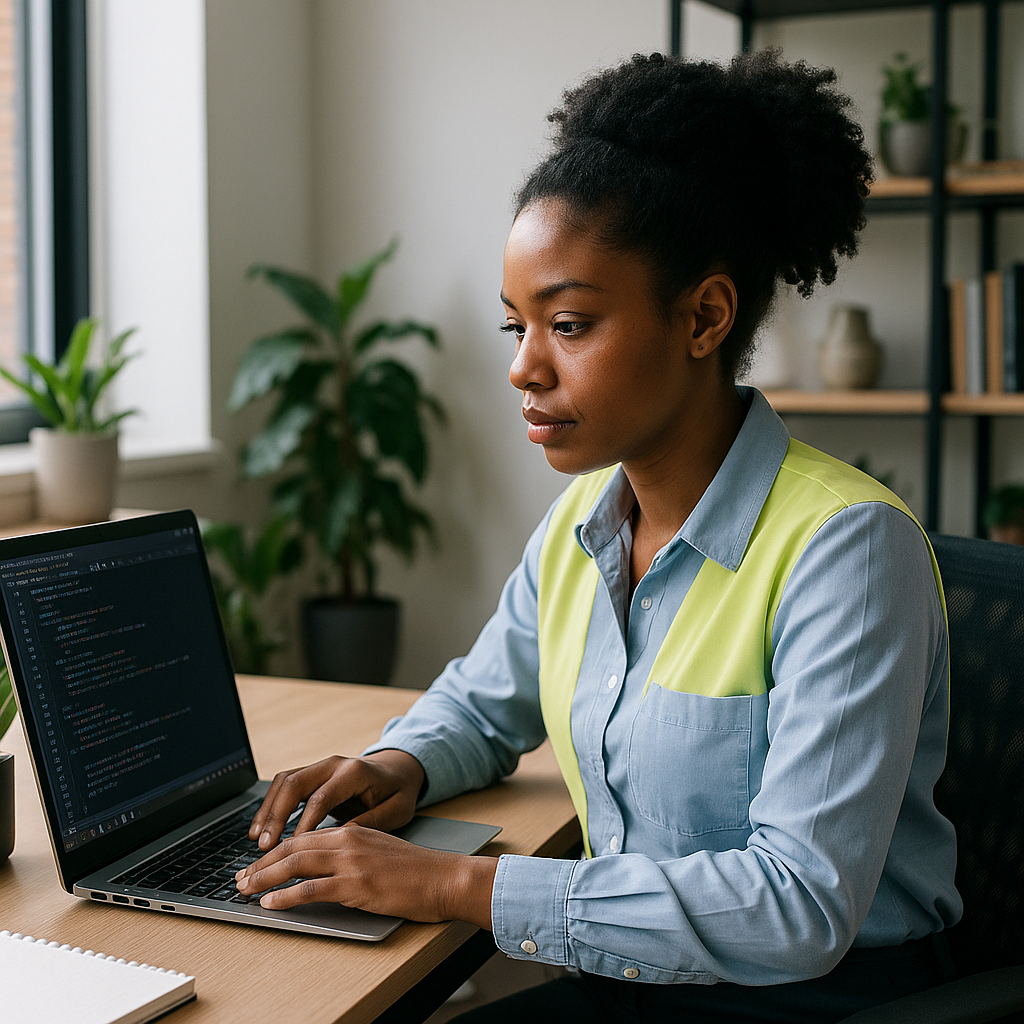

In [42]:
# Décodage et affichage de l'image générée
# resp.content_blocks[0] contient le premier bloc de réponse (l'image en base64)
Image(base64.b64decode(resp.content_blocks[0]['base64']))

In [43]:
# === ANALYSE D'IMAGE AVEC MODÈLE VISION ===

# Définition du chemin vers l'image à analyser
path = "img.png"

In [44]:
# Initialisation d'un modèle GPT-5.2 (hypothétique) avec capacités vision
llm5 = ChatOpenAI(model="gpt-5.2")

In [45]:
# Lecture et encodage de l'image en base64 pour l'envoi à l'API
with open(path, "rb") as file:
    # Lecture en mode binaire et encodage base64
    img = base64.b64encode(file.read()).decode('utf-8')

In [46]:
# Envoi de l'image au modèle avec une question sur son contenu
resp5 = llm5.invoke(input=[
    HumanMessage(content=[
    {"type":"text","text":"Qu'est ce que tu vois dans cette image"},
    {"type":"image_url", "image_url": {"url": f"data:image/png;base64,{img}"}}
])])

In [47]:
# Affichage de la description de l'image générée par le modèle
print(display(Markdown(resp5.content)))

Je vois un schéma qui illustre une architecture **RAG (Retrieval-Augmented Generation)** :

- Un **PDF** est d’abord **découpé en “chunks”** (C1, C2, C3).
- Chaque chunk est transformé en **embeddings** (vecteurs de nombres) puis stocké dans une **base de données** (souvent une base vectorielle).
- Une **User App** envoie une **requête** à une **RAG App**.
- La RAG App utilise la requête pour **retrouver du contexte pertinent** dans la base (recherche par embeddings).
- Elle envoie au **LLM** un message composé de **System message + Query + Context**, via **HTTP/JSON**.
- Le **LLM** renvoie une **réponse**, que la RAG App renvoie ensuite à l’utilisateur.

À droite, il y a aussi une **photo d’une personne** dans un encadré (je ne peux pas l’identifier).

None


In [48]:
# === CONFIGURATION DU PROMPT D'ANALYSE DE SENTIMENTS ASPECTUELS ===
system_message="""
Vous êtes un expert dans l'analyse des entiments.
Vous êtes un expert  dans l'analyse de sentiments.
Effectuez une analyse de sentiments basées sur les aspects des avis concernants les ordinateurs  portable 
Chaque avis peut comporter un ou plusieurs des aspects suivants: screen, keyboard, pad.
Pour chaque avis présenté en entrée:
- Identifiez la présence d'au moins un des trois aspects(screen, keydoard, pad)
- Attribuez une polarité de sentiment(positive, négative ou neutral) à chaque aspect. 
Organisez votre réponse dans un objet JSON avec les en-têtes suivantes :
    -category: [liste des aspects]
    -polarity: [listes des polarités correspondantes pour chaque aspect]
Si l'un des aspects n'est pas présent dans l'avis de l'utilisateur, tu supposes que la popularité est neutre
"""

In [49]:
# Initialisation du modèle GPT-5.2 (hypothétique)
llm6 = ChatOpenAI(model="gpt-5.2")

In [50]:
# Envoi de la requête avec le prompt système et l'avis utilisateur
resp = llm6.invoke(input=[
    SystemMessage(system_message),
    HumanMessage("j'ai beaucoup aimé l'écran! La souris n'est pas bonne et le clavier ma fih tchah") # Avis à analyser
])

In [51]:
# Affichage de la réponse brute du modèle (format JSON)
print(resp.content)

```json
{
  "category": ["screen", "keyboard", "pad"],
  "polarity": ["positive", "negative", "negative"]
}
```


In [52]:
# Import du module JSON pour parser la réponse
import json

In [53]:
# Nettoyage et parsing de la réponse JSON
sentiment=json.loads(resp.content.replace("```json", "").replace("```", ""))

In [54]:
# Affichage de l'objet JSON parsé
print(sentiment)

{'category': ['screen', 'keyboard', 'pad'], 'polarity': ['positive', 'negative', 'negative']}


In [55]:
# Affichage des catégories (aspects) extraits
print(sentiment['category'])

['screen', 'keyboard', 'pad']


In [56]:
# Affichage des polarités correspondantes
print(sentiment['polarity'])

['positive', 'negative', 'negative']
